In [56]:
#kaggleのBankCustomerChurnデータセットを利用して顧客離脱するかしないかの二値分類モデルを作成
# 必要なライブラリのimport
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Tensorflow
import tensorflow as tf

# データの分割
from sklearn.model_selection import train_test_split

# MSE
from sklearn.metrics import mean_squared_error

# DataFrameで全ての列を表示する設定
pd.options.display.max_columns = None

In [57]:
#csvファイルをimport
dataset_base = pd.read_csv("Customer-Churn-Records.csv")
dataset_base.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [58]:
#列の抜き出し
dataset = dataset_base.iloc[ : , 4: ]
dataset.head()

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [59]:
#データ内容の確認
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [60]:
# カテゴリ変数をダミー変数に変換
dataset_1 = pd.get_dummies(dataset, columns=["Geography", "Gender", "Card Type"])
dataset_1.head()

,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Card Type_DIAMOND,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,42,2,0.00,1,1,1,101348.88,1,1,2,464,True,False,False,True,False,True,False,False,False
1,41,1,83807.86,1,0,1,112542.58,0,1,3,456,False,False,True,True,False,True,False,False,False
2,42,8,159660.80,3,1,0,113931.57,1,1,3,377,True,False,False,True,False,True,False,False,False
3,39,1,0.00,2,0,0,93826.63,0,0,5,350,True,False,False,True,False,False,True,False,False
4,43,2,125510.82,1,1,1,79084.10,0,0,5,425,False,False,True,True,False,False,True,False,False


In [87]:
dataset_1.corr()["Exited"].sort_values(ascending=False)


Exited                1.000000
Complain              0.995693
Age                   0.285296
Geography_Germany     0.173313
Balance               0.118577
Gender_Female         0.106267
Card Type_DIAMOND     0.020089
EstimatedSalary       0.012490
Card Type_PLATINUM   -0.000276
Card Type_SILVER     -0.003834
Point Earned         -0.004628
Satisfaction Score   -0.005849
HasCrCard            -0.006976
Tenure               -0.013656
Card Type_GOLD       -0.015995
NumOfProducts        -0.047611
Geography_Spain      -0.052800
Geography_France     -0.104688
Gender_Male          -0.106267
IsActiveMember       -0.156356
Name: Exited, dtype: float64

In [93]:
# 説明変数 X と目的変数 y を作成
X = dataset_1.drop("Exited", axis=1)
Y = dataset_1["Exited"]

#形状を確認
print("Y=",Y.shape, ", X=",X.shape)

# データ分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, random_state=0)


Y= (10000,) , X= (10000, 19)


In [94]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (4900,) , X_train= (4900, 19)
Y_valid= (2100,) , X_valid= (2100, 19)
Y_test= (3000,) , X_test= (3000, 19)


In [98]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    # 隠れ層
    tf.keras.layers.Dense(8, activation='relu'),
    # 出力層
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# モデルの構築
model.compile(optimizer = "rmsprop", loss='binary_crossentropy', metrics=['accuracy'])

In [99]:
# モデルの構造を表示
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 8)              │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [100]:
%%time
# 学習の実施
log = model.fit(X_train, Y_train, epochs=200, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                            min_delta=0, patience=100,
                                                            verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6473 - loss: 928.1918 - val_accuracy: 0.5419 - val_loss: 261.5841
Epoch 2/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6676 - loss: 145.6580 - val_accuracy: 0.6910 - val_loss: 102.5557
Epoch 3/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6729 - loss: 94.2709 - val_accuracy: 0.3324 - val_loss: 128.6042
Epoch 4/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6733 - loss: 79.7164 - val_accuracy: 0.4986 - val_loss: 219.3395
Epoch 5/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6718 - loss: 72.5663 - val_accuracy: 0.7629 - val_loss: 50.5898
Epoch 6/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6747 - loss: 65.1875 - val_accuracy: 0.8062 - val_loss: 91.2386
Epoch 7/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6743 - loss: 58.6628 - val_accuracy: 0.5638 - val_loss: 53.3110
Epoch 8/200
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6778 - lo

Text(0, 0.5, 'crossentropy')

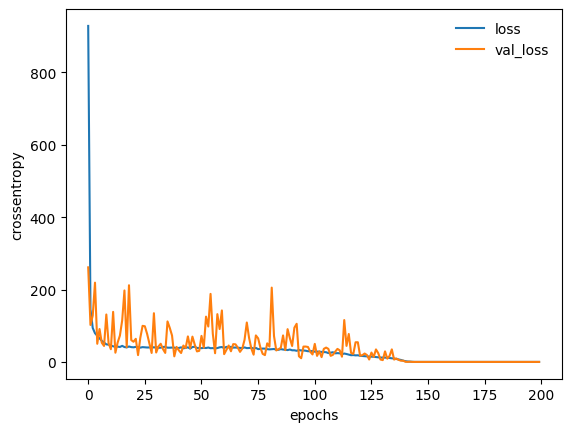

In [101]:
# グラフ表示
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [102]:
# predictで予測を行なう
Y_pred = model.predict(X_test)
Y_pred

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[0.22010723],
       [0.22010723],
       [0.22010723],
       ...,
       [0.22010723],
       [0.22010723],
       [0.22010723]], dtype=float32)

In [107]:
# 二値分類は予測結果の確率が0.5以下なら0,
# それより大きければ1となる計算で求める
Y_pred_cls = (Y_pred > 0.3).astype("int32")
Y_pred_cls

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], dtype=int32)

In [108]:
# 形状を正解（目的変数）に合わせる
Y_pred_ = Y_pred_cls.reshape(-1)

In [109]:
# モデルの評価
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred_))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88      2378
           1       0.00      0.00      0.00       622

    accuracy                           0.79      3000
   macro avg       0.40      0.50      0.44      3000
weighted avg       0.63      0.79      0.70      3000



c:\Users\na2ki\Downloads\aidev\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\na2ki\Downloads\aidev\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\na2ki\Downloads\aidev\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
